In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

In [14]:
# ==========================================
# Part 1: Data Loading & Preprocessing
# ==========================================
def load_and_preprocess_data(filepath):
    # Load dataset
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print("Error: File not found.")
        return None

    # 1. Handle Target 'num' -> Binary 0 or 1
    if 'num' in df.columns:
        df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
        df = df.drop(columns=['num'])
    
    # 2. Drop Metadata 'dataset' column shown in your CSV image
    if 'dataset' in df.columns:
        df = df.drop(columns=['dataset'])

    # Separate Features and Target
    X = df.drop(columns=['target']).values
    y = df['target'].values
    
    # 3. Stratified Split (Allowed sklearn utility)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=42
    )
    
    # 4. Feature Scaling (Manual Z-score logic using NumPy)
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1.0 # Avoid division by zero
    
    X_train_scaled = (X_train - mu) / sigma
    X_test_scaled = (X_test - mu) / sigma
    
    return X_train_scaled, X_test_scaled, y_train, y_test

### ESLogisticRegression Parameters

This class implements a self-adaptive Evolution Strategy (ES) for binary logistic regression.

- `input_dim`: Number of input features (`d`) in the dataset.
- `mu`: Number of parent individuals kept each generation.
- `lam`: Number of offspring generated each generation (`lambda`).
- `n_gen`: Number of generations (optimization iterations).
- `l2_lambda`: L2 regularization coefficient used in the loss (`CE + l2_lambda * ||W||^2`).

Derived internal quantities:
- `n = input_dim + 1`: Total parameter count (weights + bias).
- `tau` and `tau_prime`: Global/local self-adaptation learning rates for mutating step sizes (`sigma`).


### Part 2.1 - Prediction Utilities

These helper functions implement the logistic-regression forward pass using only NumPy.

- `es_sigmoid`: numerically-stable sigmoid
- `es_predict_proba`: probability output from `theta = [W, b]`
- `es_predict`: binary prediction with threshold 0.5


In [15]:
# ==========================================
# Part 2.1: Prediction Utilities (Pure NumPy)
# ==========================================

# we use sigmoid in order to classify if the paitent is truly detected or not
def es_sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))


def es_predict_proba(X, theta):
    W = theta[:-1]
    b = theta[-1]
    return es_sigmoid(np.dot(X, W) + b)


def es_predict(X, theta):
    return (es_predict_proba(X, theta) >= 0.5).astype(int)

### Part 2.2 - Loss and Fitness

This section defines the optimization objective used by ES.

- Loss: cross-entropy + L2 regularization on weights only
- Fitness: negative loss (because ES selects by maximum fitness)


In [16]:
# ==========================================
# Part 2.2: Loss and Fitness (Pure NumPy)
# ==========================================
def es_compute_loss(X, y, theta, l2_lambda):
    N = len(y)
    y_hat = es_predict_proba(X, theta)
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    ce = -(1 / N) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    W = theta[:-1]
    reg = l2_lambda * np.sum(W ** 2)
    return ce + reg


def es_compute_fitness(X, y, theta, l2_lambda):
    return -es_compute_loss(X, y, theta, l2_lambda)


### Part 2.3 - Population Initialization and Mutation

This is the self-adaptive ES mechanics.

- Initialize each individual as `{theta, sigma, fitness}`
- Mutate `sigma` with global/local Gaussian factors (`tau`, `tau_prime`)
- Mutate `theta` using the new `sigma` and apply stability clipping


In [17]:
# ==========================================
# Part 2.3: Population and Mutation
# ==========================================
def es_initialize_population(mu, n):
    population = []
    for _ in range(mu):
        theta = np.random.uniform(-0.1, 0.1, n)
        sigma = np.random.uniform(0.01, 0.1, n)
        population.append({'theta': theta, 'sigma': sigma, 'fitness': None})
    return population


def es_mutate(individual, tau, tau_prime, n):
    theta = individual['theta']
    sigma = individual['sigma']

    global_noise = np.random.normal(0, 1)
    local_noise = np.random.normal(0, 1, n)

    sigma_prime = sigma * np.exp(tau * global_noise + tau_prime * local_noise)
    sigma_prime = np.maximum(sigma_prime, 1e-6)

    param_noise = np.random.normal(0, 1, n)
    theta_prime = theta + sigma_prime * param_noise
    theta_prime = np.clip(theta_prime, -5, 5)

    return {'theta': theta_prime, 'sigma': sigma_prime, 'fitness': None}


### Part 2.4 - ES Training Loop (`(mu + lambda)` Selection)

This function runs generations of ES optimization. For each generation it:

1. Samples `lambda` offspring from current parents
2. Evaluates fitness on the training set
3. Applies elitist `(mu + lambda)` selection
4. Logs loss and accuracy history for analysis


In [18]:
# ==========================================
# Part 2.4: ES Training Loop
# ==========================================
def es_fit(X_train, y_train, X_test, y_test, mu, lam, n_gen, n, tau, tau_prime, l2_lambda):
    history = {'best_fitness': [], 'mean_fitness': [], 'train_acc': [], 'test_acc': []}
    population = es_initialize_population(mu, n)

    for ind in population:
        ind['fitness'] = es_compute_fitness(X_train, y_train, ind['theta'], l2_lambda)

    print(f"Starting ES Training (Generations: {n_gen})...")

    for gen in range(n_gen):
        offspring = []

        for _ in range(lam):
            parent = population[np.random.randint(0, mu)]
            child = es_mutate(parent, tau, tau_prime, n)
            child['fitness'] = es_compute_fitness(X_train, y_train, child['theta'], l2_lambda)
            offspring.append(child)

        pool = population + offspring
        pool.sort(key=lambda x: x['fitness'], reverse=True)
        population = pool[:mu]

        best_ind = population[0]
        current_loss = -best_ind['fitness']
        mean_loss = -np.mean([ind['fitness'] for ind in population])

        train_acc = accuracy_score(y_train, es_predict(X_train, best_ind['theta']))
        test_acc = accuracy_score(y_test, es_predict(X_test, best_ind['theta']))

        history['best_fitness'].append(current_loss)
        history['mean_fitness'].append(mean_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)

        if (gen + 1) % 10 == 0:
            print(
                f"Gen {gen + 1}: Loss={current_loss:.4f}, Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}"
            )

    return population[0], history


### Part 2.5 - Class Wrapper (`ESLogisticRegression`)

This class provides the same public API used in the rest of the notebook:

- `fit(...)` to train
- `predict(...)` and `predict_proba(...)` for inference
- `history` to visualize convergence

Internally, it delegates heavy lifting to the helper functions above.


In [19]:
# ==========================================
# Part 2.5: ESLogisticRegression Class
# ==========================================
class ESLogisticRegression:
    def __init__(self, input_dim, mu=30, lam=210, n_gen=100, l2_lambda=0.01):
        self.d = input_dim
        self.n = input_dim + 1  # Weights + Bias
        self.mu = mu
        self.lam = lam
        self.n_gen = n_gen
        self.l2_lambda = l2_lambda

        self.tau = 1.0 / np.sqrt(2 * self.n)
        self.tau_prime = 1.0 / np.sqrt(2 * np.sqrt(self.n))

        self.history = {'best_fitness': [], 'mean_fitness': [], 'train_acc': [], 'test_acc': []}
        self.population = []

    def predict_proba(self, X, theta):
        return es_predict_proba(X, theta)

    def predict(self, X, theta):
        return es_predict(X, theta)

    def compute_loss(self, X, y, theta):
        return es_compute_loss(X, y, theta, self.l2_lambda)

    def compute_fitness(self, X, y, theta):
        return es_compute_fitness(X, y, theta, self.l2_lambda)

    def fit(self, X_train, y_train, X_test, y_test):
        best_individual, history = es_fit(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            mu=self.mu,
            lam=self.lam,
            n_gen=self.n_gen,
            n=self.n,
            tau=self.tau,
            tau_prime=self.tau_prime,
            l2_lambda=self.l2_lambda,
        )

        self.history = history
        self.population = [best_individual]
        return best_individual


In [20]:
# ==========================================
# Part 3: Running the Experiment
# ==========================================
def run_experiment():
    # 1. Load Data
    csv_path = 'Heart Disease dataset.csv' # CHANGE THIS TO YOUR FILE PATH
    data = load_and_preprocess_data(csv_path)
    if data is None: return

    X_train, X_test, y_train, y_test = data
    
    # 2. Run Algorithm
    es = ESLogisticRegression(input_dim=X_train.shape[1])
    best_solution = es.fit(X_train, y_train, X_test, y_test)
    
    # 3. Plotting
    gens = range(1, len(es.history['best_fitness']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(gens, es.history['best_fitness'], label='Best Loss')
    plt.plot(gens, es.history['mean_fitness'], label='Mean Loss', linestyle='--')
    plt.title('Loss over Generations')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(gens, es.history['train_acc'], label='Train Acc')
    plt.plot(gens, es.history['test_acc'], label='Test Acc')
    plt.title('Accuracy over Generations')
    plt.legend()
    
    plt.tight_layout()
    plt.show() #     
    # 4. Final Metrics
    print("\n--- Final Results ---")
    best_theta = best_solution['theta']
    y_pred = es.predict(X_test, best_theta)
    
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() # 

Starting ES Training (Generations: 100)...
Gen 10: Loss=0.3438, Train Acc=0.8427, Test Acc=0.8689
Gen 20: Loss=0.3294, Train Acc=0.8709, Test Acc=0.8962
Gen 30: Loss=0.3261, Train Acc=0.8826, Test Acc=0.8852
Gen 40: Loss=0.3257, Train Acc=0.8826, Test Acc=0.8907
Gen 50: Loss=0.3255, Train Acc=0.8779, Test Acc=0.9016
Gen 60: Loss=0.3253, Train Acc=0.8826, Test Acc=0.9071
Gen 70: Loss=0.3252, Train Acc=0.8803, Test Acc=0.9126
Gen 80: Loss=0.3243, Train Acc=0.8779, Test Acc=0.8907
Gen 90: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 100: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016


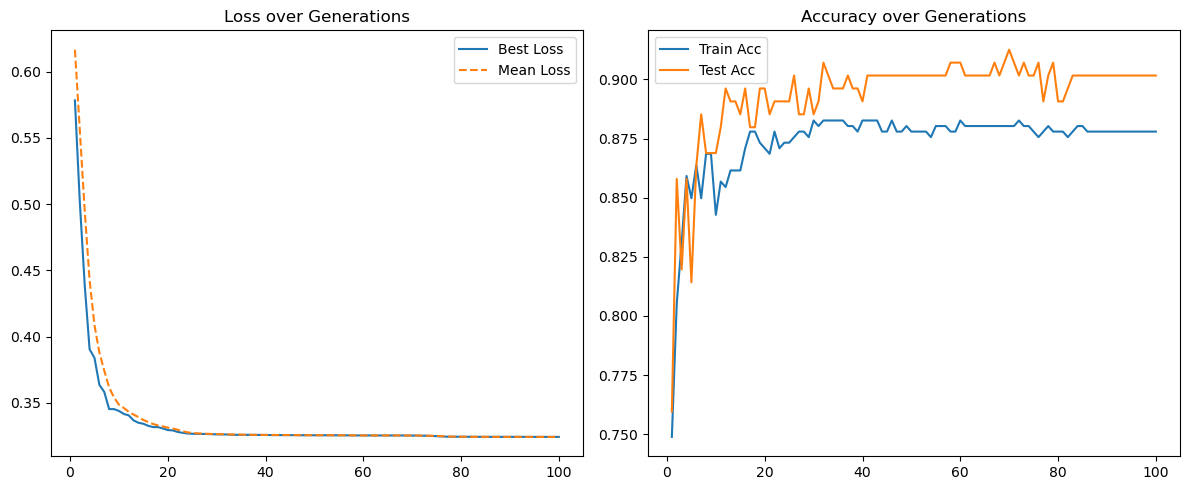


--- Final Results ---
Accuracy: 0.9016
Precision: 0.8902
Recall: 0.8902
F1: 0.8902


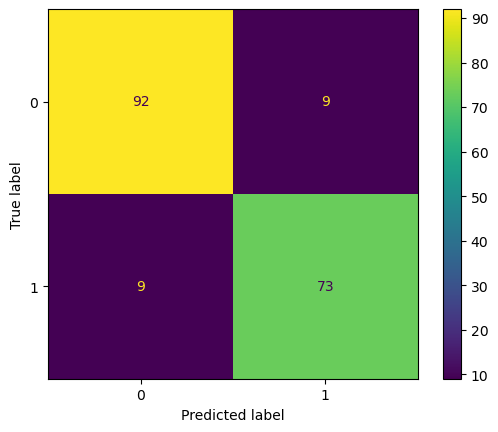

In [21]:
if __name__ == "__main__":
    run_experiment()

Starting ES Training (Generations: 100)...
Gen 10: Loss=0.3375, Train Acc=0.8662, Test Acc=0.8962
Gen 20: Loss=0.3318, Train Acc=0.8638, Test Acc=0.8907
Gen 30: Loss=0.3278, Train Acc=0.8779, Test Acc=0.9016
Gen 40: Loss=0.3256, Train Acc=0.8850, Test Acc=0.8962
Gen 50: Loss=0.3243, Train Acc=0.8779, Test Acc=0.9071
Gen 60: Loss=0.3243, Train Acc=0.8756, Test Acc=0.8962
Gen 70: Loss=0.3242, Train Acc=0.8756, Test Acc=0.9016
Gen 80: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 90: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 100: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016


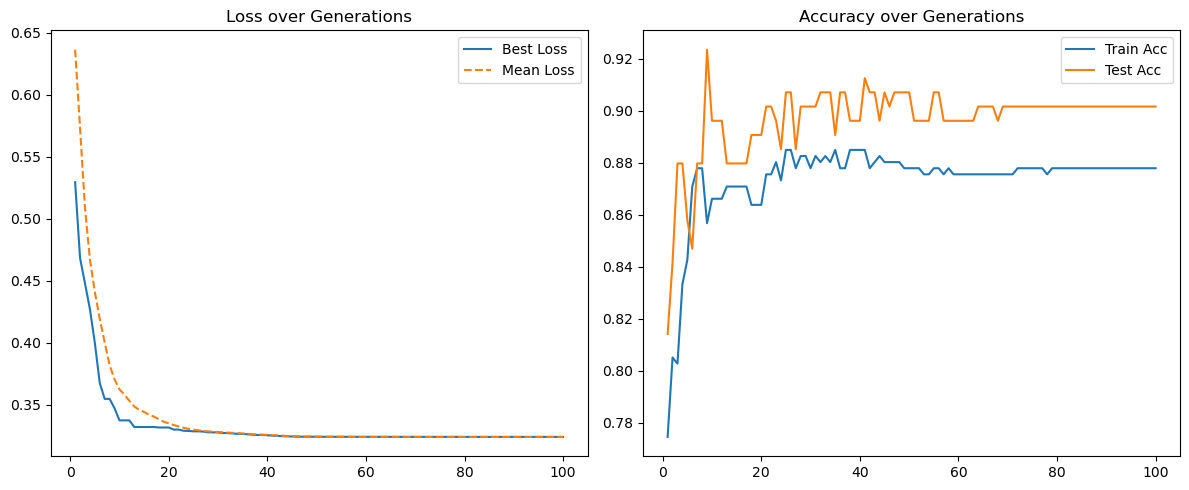


--- Final Results ---
Accuracy: 0.9016
Precision: 0.8902
Recall: 0.8902
F1: 0.8902


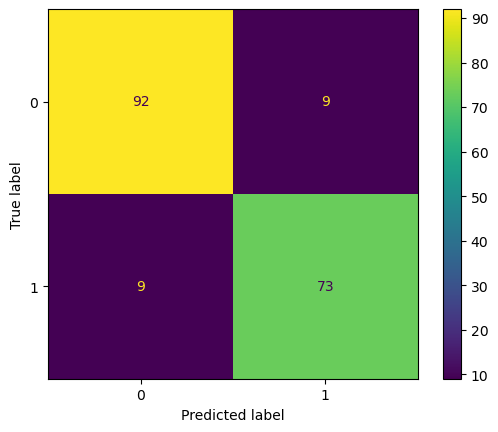

In [22]:
# ==========================================
# Part 3: Running the Experiment
# ==========================================
def run_experiment():
    # 1. Load Data
    csv_path = 'Heart Disease dataset.csv' # CHANGE THIS TO YOUR FILE PATH
    data = load_and_preprocess_data(csv_path)
    if data is None: return

    X_train, X_test, y_train, y_test = data
    
    # 2. Run Algorithm
    es = ESLogisticRegression(input_dim=X_train.shape[1], lam=250, mu=50)
    best_solution = es.fit(X_train, y_train, X_test, y_test)
    
    # 3. Plotting
    gens = range(1, len(es.history['best_fitness']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(gens, es.history['best_fitness'], label='Best Loss')
    plt.plot(gens, es.history['mean_fitness'], label='Mean Loss', linestyle='--')
    plt.title('Loss over Generations')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(gens, es.history['train_acc'], label='Train Acc')
    plt.plot(gens, es.history['test_acc'], label='Test Acc')
    plt.title('Accuracy over Generations')
    plt.legend()
    
    plt.tight_layout()
    plt.show() #     
    # 4. Final Metrics
    print("\n--- Final Results ---")
    best_theta = best_solution['theta']
    y_pred = es.predict(X_test, best_theta)
    
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() # 
    
if __name__ == "__main__":
    run_experiment()

Starting ES Training (Generations: 100)...
Gen 10: Loss=0.3394, Train Acc=0.8685, Test Acc=0.8907
Gen 20: Loss=0.3247, Train Acc=0.8779, Test Acc=0.8907
Gen 30: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 40: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 50: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 60: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 70: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 80: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 90: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016
Gen 100: Loss=0.3242, Train Acc=0.8779, Test Acc=0.9016


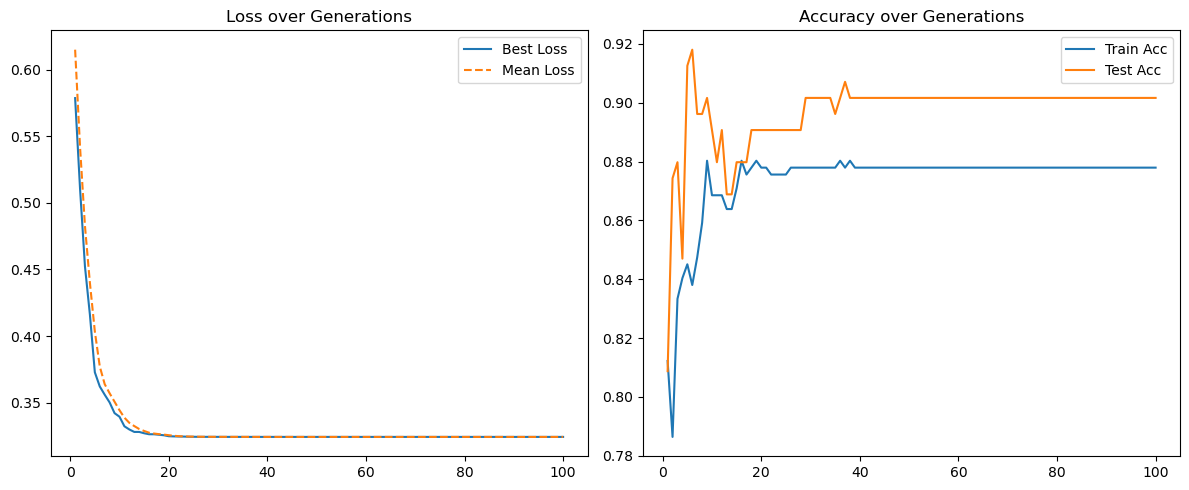


--- Final Results ---
Accuracy: 0.9016
Precision: 0.8902
Recall: 0.8902
F1: 0.8902


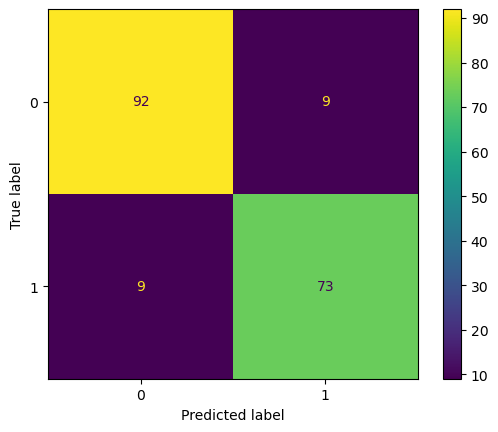

In [23]:
# ==========================================
# Part 3: Running the Experiment
# ==========================================
def run_experiment():
    # 1. Load Data
    csv_path = 'Heart Disease dataset.csv' # CHANGE THIS TO YOUR FILE PATH
    data = load_and_preprocess_data(csv_path)
    if data is None: return

    X_train, X_test, y_train, y_test = data
    
    # 2. Run Algorithm
    es = ESLogisticRegression(input_dim=X_train.shape[1], lam=400, mu=30)
    best_solution = es.fit(X_train, y_train, X_test, y_test)
    
    # 3. Plotting
    gens = range(1, len(es.history['best_fitness']) + 1)
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(gens, es.history['best_fitness'], label='Best Loss')
    plt.plot(gens, es.history['mean_fitness'], label='Mean Loss', linestyle='--')
    plt.title('Loss over Generations')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(gens, es.history['train_acc'], label='Train Acc')
    plt.plot(gens, es.history['test_acc'], label='Test Acc')
    plt.title('Accuracy over Generations')
    plt.legend()
    
    plt.tight_layout()
    plt.show() #     
    # 4. Final Metrics
    print("\n--- Final Results ---")
    best_theta = best_solution['theta']
    y_pred = es.predict(X_test, best_theta)
    
    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall: {r:.4f}")
    print(f"F1: {f1:.4f}")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show() # 
    
if __name__ == "__main__":
    run_experiment()

### Extra Run: L2 Regularization = 0.1

This cell runs the same ES experiment with stronger L2 regularization (`l2_lambda=0.1`) and saves the output plots.


Starting ES Training (Generations: 100)...
Gen 10: Loss=0.4544, Train Acc=0.8709, Test Acc=0.9071
Gen 20: Loss=0.4459, Train Acc=0.8732, Test Acc=0.9126
Gen 30: Loss=0.4449, Train Acc=0.8685, Test Acc=0.9126
Gen 40: Loss=0.4448, Train Acc=0.8662, Test Acc=0.9071
Gen 50: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071
Gen 60: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071
Gen 70: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071
Gen 80: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071
Gen 90: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071
Gen 100: Loss=0.4448, Train Acc=0.8685, Test Acc=0.9071


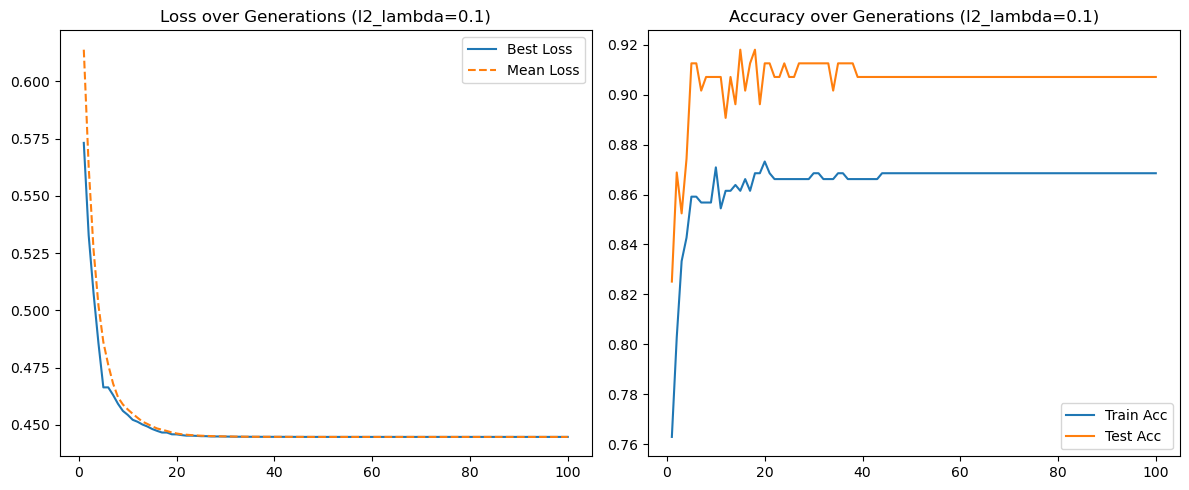


--- Final Results (l2_lambda=0.1) ---
Accuracy: 0.9071
Precision: 0.8916
Recall: 0.9024
F1: 0.8970


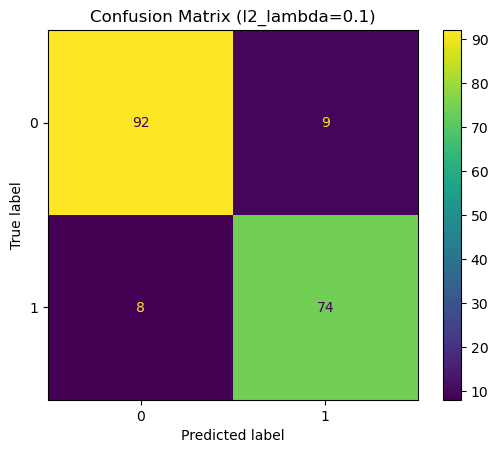

In [24]:
# ==========================================
# Part 4: Extra Experiment with l2_lambda=0.1
# ==========================================
def run_experiment_l2_01():
    csv_path = 'Heart Disease dataset.csv'
    data = load_and_preprocess_data(csv_path)
    if data is None:
        return

    X_train, X_test, y_train, y_test = data

    es = ESLogisticRegression(input_dim=X_train.shape[1], lam=400, mu=30, l2_lambda=0.1)
    best_solution = es.fit(X_train, y_train, X_test, y_test)

    gens = range(1, len(es.history['best_fitness']) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(gens, es.history['best_fitness'], label='Best Loss')
    plt.plot(gens, es.history['mean_fitness'], label='Mean Loss', linestyle='--')
    plt.title('Loss over Generations (l2_lambda=0.1)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(gens, es.history['train_acc'], label='Train Acc')
    plt.plot(gens, es.history['test_acc'], label='Test Acc')
    plt.title('Accuracy over Generations (l2_lambda=0.1)')
    plt.legend()

    plt.tight_layout()
    plt.savefig('accuracy_plot_l2_0_1.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n--- Final Results (l2_lambda=0.1) ---')
    best_theta = best_solution['theta']
    y_pred = es.predict(X_test, best_theta)

    acc = accuracy_score(y_test, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')

    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall: {r:.4f}')
    print(f'F1: {f1:.4f}')

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title('Confusion Matrix (l2_lambda=0.1)')
    plt.savefig('confusion_matrix_l2_0_1.png', dpi=150, bbox_inches='tight')
    plt.show()


run_experiment_l2_01()
